# Classical ML Foundations

**Author:** Ihor Melashchenko  
**Student ID:** C00290950  

## Preliminary Submission Scope
This notebook demonstrates baseline semester 2 classical methods using synthetic student engagement data:
1. K-Means clustering
2. K-Nearest Neighbour classification
3. Support Vector Machine classification

The notebook includes EDA, hyperparameter tuning, model evaluation, and saved figures for portfolio evidence.

In [1]:
# Author: Ihor Melashchenko
# Student ID: C00290950

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_generation import DatasetConfig, generate_student_dataset

RESULTS_DIR = PROJECT_ROOT / 'results' / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
config = DatasetConfig(n_students=600, random_seed=42)
df = generate_student_dataset(config=config)

display(df.head())
display(df.describe().T[['mean', 'std', 'min', 'max']])

df.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'student_retention_dataset_v2.csv', index=False)
print('Saved dataset to data/processed/student_retention_dataset_v2.csv')

,weekly_logins,avg_session_minutes,timetable_views,notification_click_rate,attendance_rate,assignment_submission_rate,gpa,engagement_score,dropout_risk
0,9.91,21.09,8.06,0.489,0.779,0.769,3.05,0.601,0
1,5.88,14.53,13.08,0.395,0.824,0.791,3.24,0.545,0
2,11.25,25.65,18.52,0.793,0.856,0.718,3.60,0.711,0
3,11.82,14.23,15.39,0.468,0.886,0.777,2.33,0.643,0
4,3.15,14.18,12.10,0.483,0.804,0.774,3.35,0.507,0


,mean,std,min,max
weekly_logins,8.922950,2.916944,1.000,17.740
avg_session_minutes,17.908417,5.934965,3.000,37.070
timetable_views,15.527767,6.231614,0.000,33.490
notification_click_rate,0.451877,0.191586,0.023,0.928
attendance_rate,0.814995,0.113790,0.443,1.000
assignment_submission_rate,0.771840,0.148401,0.321,1.000
gpa,2.730367,0.687735,0.800,4.000
engagement_score,0.606133,0.063524,0.391,0.779
dropout_risk,0.330000,0.470605,0.000,1.000


Saved dataset to data/processed/student_retention_dataset_v2.csv


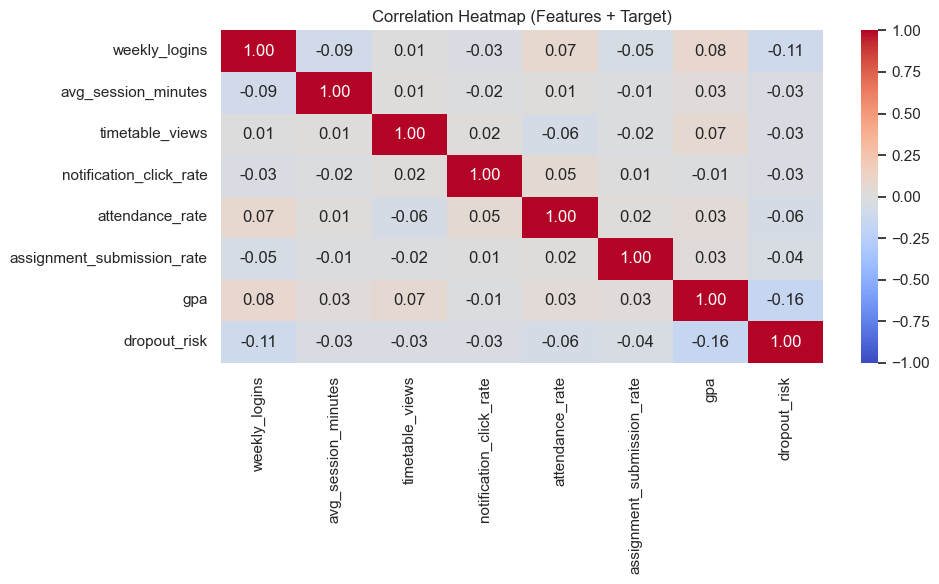

In [3]:
feature_cols = [
    'weekly_logins',
    'avg_session_minutes',
    'timetable_views',
    'notification_click_rate',
    'attendance_rate',
    'assignment_submission_rate',
    'gpa',
]
target_col = 'dropout_risk'

X = df[feature_cols]
y = df[target_col]

plt.figure(figsize=(10, 6))
corr = df[feature_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Features + Target)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_correlation_heatmap.png', dpi=150)
plt.show()

## 2) K-Means Clustering (Elbow + Silhouette + PCA View)

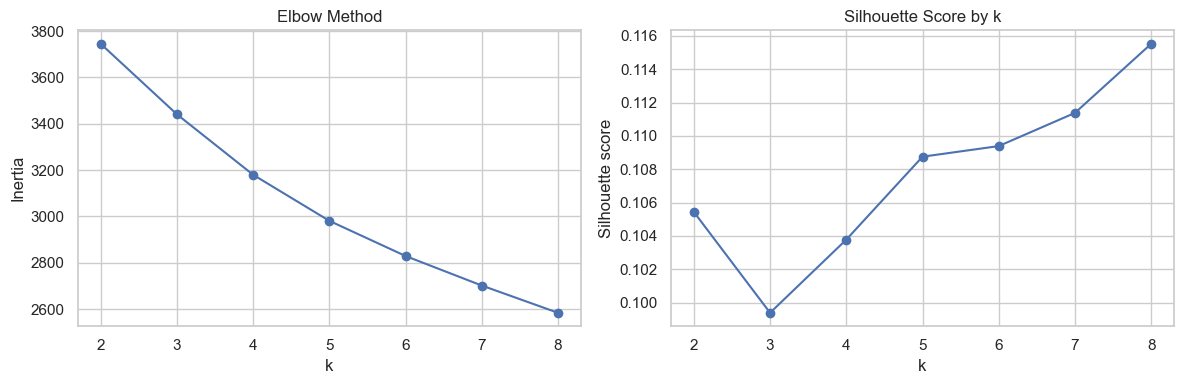

In [4]:
X_scaled = StandardScaler().fit_transform(X)

k_values = list(range(2, 9))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_values, silhouettes, marker='o')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_kmeans_selection.png', dpi=150)
plt.show()

Silhouette score (k=3): 0.099


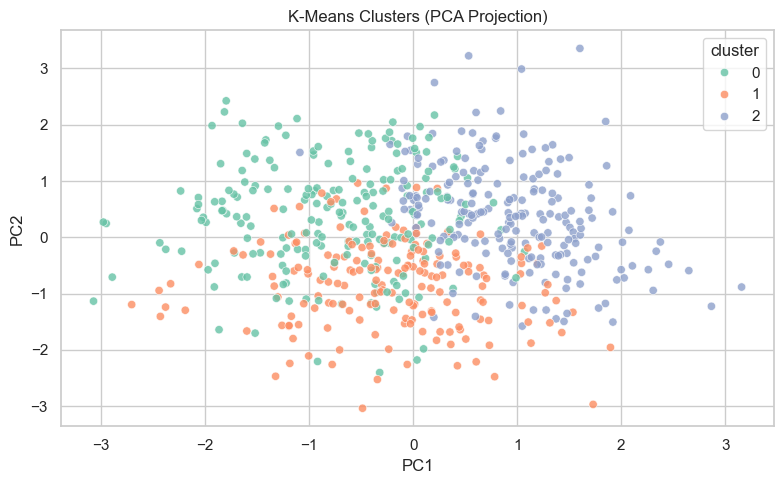

,weekly_logins,avg_session_minutes,timetable_views,notification_click_rate,attendance_rate,assignment_submission_rate,gpa
cluster,,,,,,,
0,7.127,16.800,18.040,0.489,0.741,0.833,2.578
1,8.486,18.969,9.925,0.380,0.855,0.740,2.424
2,11.031,18.079,17.860,0.477,0.852,0.740,3.138


In [5]:
best_k = 3
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_scaled)

df['cluster'] = cluster_labels
cluster_sil = silhouette_score(X_scaled, cluster_labels)
print(f'Silhouette score (k={best_k}): {cluster_sil:.3f}')

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({'PC1': X_2d[:, 0], 'PC2': X_2d[:, 1], 'cluster': cluster_labels})

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster', palette='Set2', alpha=0.8)
plt.title('K-Means Clusters (PCA Projection)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_kmeans_pca_clusters.png', dpi=150)
plt.show()

cluster_profile = df.groupby('cluster')[feature_cols].mean().round(3)
display(cluster_profile)

## 3) Classification: KNN and SVM with Hyperparameter Tuning

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()),
])

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42)),
])

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid={'knn__n_neighbors': [3, 5, 7, 9], 'knn__weights': ['uniform', 'distance']},
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid={'svm__C': [0.5, 1.0, 2.0, 5.0], 'svm__kernel': ['linear', 'rbf']},
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

knn_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)

print('Best KNN params:', knn_grid.best_params_)
print('Best SVM params:', svm_grid.best_params_)

Best KNN params: {'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best SVM params: {'svm__C': 5.0, 'svm__kernel': 'rbf'}


,Model,Accuracy,ROC_AUC
0,KNN (tuned),0.533,0.440
1,SVM (tuned),0.617,0.416


KNN Classification Report
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        80
           1       0.23      0.17      0.20        40

    accuracy                           0.53       120
   macro avg       0.43      0.44      0.44       120
weighted avg       0.50      0.53      0.51       120

SVM Classification Report
              precision    recall  f1-score   support

           0       0.67      0.85      0.75        80
           1       0.33      0.15      0.21        40

    accuracy                           0.62       120
   macro avg       0.50      0.50      0.48       120
weighted avg       0.56      0.62      0.57       120



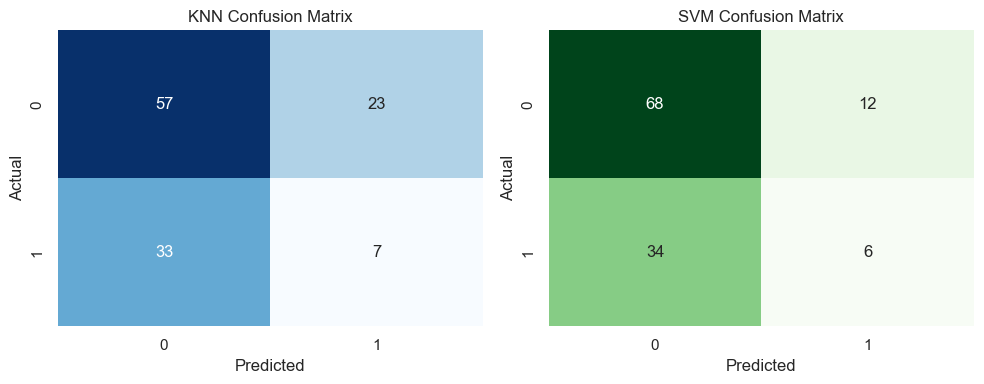

In [7]:
best_knn = knn_grid.best_estimator_
best_svm = svm_grid.best_estimator_

pred_knn = best_knn.predict(X_test)
pred_svm = best_svm.predict(X_test)

proba_knn = best_knn.predict_proba(X_test)[:, 1]
proba_svm = best_svm.predict_proba(X_test)[:, 1]

metrics_table = pd.DataFrame([
    {
        'Model': 'KNN (tuned)',
        'Accuracy': accuracy_score(y_test, pred_knn),
        'ROC_AUC': roc_auc_score(y_test, proba_knn),
    },
    {
        'Model': 'SVM (tuned)',
        'Accuracy': accuracy_score(y_test, pred_svm),
        'ROC_AUC': roc_auc_score(y_test, proba_svm),
    },
])
metrics_table[['Accuracy', 'ROC_AUC']] = metrics_table[['Accuracy', 'ROC_AUC']].round(3)
display(metrics_table)

print('KNN Classification Report')
print(classification_report(y_test, pred_knn))
print('SVM Classification Report')
print(classification_report(y_test, pred_svm))

cm_knn = confusion_matrix(y_test, pred_knn)
cm_svm = confusion_matrix(y_test, pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_confusion_matrices.png', dpi=150)
plt.show()

## 4) Synthetic vs Real Dataset Comparison (UCI Student Performance)

> Real data source: UCI Student Performance (`student-mat.csv`).

> Dropout-risk proxy for comparison: `dropout_risk_proxy = 1` when final grade `G3 < 10`, else `0`.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

real_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'student-mat.csv', sep=';')
real_df['dropout_risk_proxy'] = (real_df['G3'] < 10).astype(int)

real_feature_cols = [column for column in real_df.columns if column not in ['G1', 'G2', 'G3', 'dropout_risk_proxy']]
X_real = real_df[real_feature_cols]
y_real = real_df['dropout_risk_proxy']

numeric_features = X_real.select_dtypes(include=['number']).columns.tolist()
categorical_features = [column for column in X_real.columns if column not in numeric_features]

real_preprocess = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
            numeric_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]),
            categorical_features,
        ),
    ]
)

X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

knn_real_pipe = Pipeline([('preprocess', real_preprocess), ('knn', KNeighborsClassifier())])
svm_real_pipe = Pipeline([('preprocess', real_preprocess), ('svm', SVC(probability=True, random_state=42))])

knn_real_grid = GridSearchCV(
    knn_real_pipe,
    param_grid={'knn__n_neighbors': [3, 5, 7, 9], 'knn__weights': ['uniform', 'distance']},
    scoring='f1',
    cv=5,
    n_jobs=-1,
    error_score='raise',
)

svm_real_grid = GridSearchCV(
    svm_real_pipe,
    param_grid={'svm__C': [0.5, 1.0, 2.0, 5.0], 'svm__kernel': ['linear', 'rbf']},
    scoring='f1',
    cv=5,
    n_jobs=-1,
    error_score='raise',
)

knn_real_grid.fit(X_real_train, y_real_train)
svm_real_grid.fit(X_real_train, y_real_train)

real_df.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'student_performance_real_processed.csv', index=False)
print('Saved processed real dataset to data/processed/student_performance_real_processed.csv')
print('Best real KNN params:', knn_real_grid.best_params_)
print('Best real SVM params:', svm_real_grid.best_params_)

Saved processed real dataset to data/processed/student_performance_real_processed.csv
Best real KNN params: {'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best real SVM params: {'svm__C': 5.0, 'svm__kernel': 'linear'}


,Dataset,Model,Accuracy,ROC_AUC
0,Real (UCI),KNN (tuned),0.570,0.485
1,Real (UCI),SVM (tuned),0.709,0.702
2,Synthetic,KNN (tuned),0.533,0.440
3,Synthetic,SVM (tuned),0.617,0.416


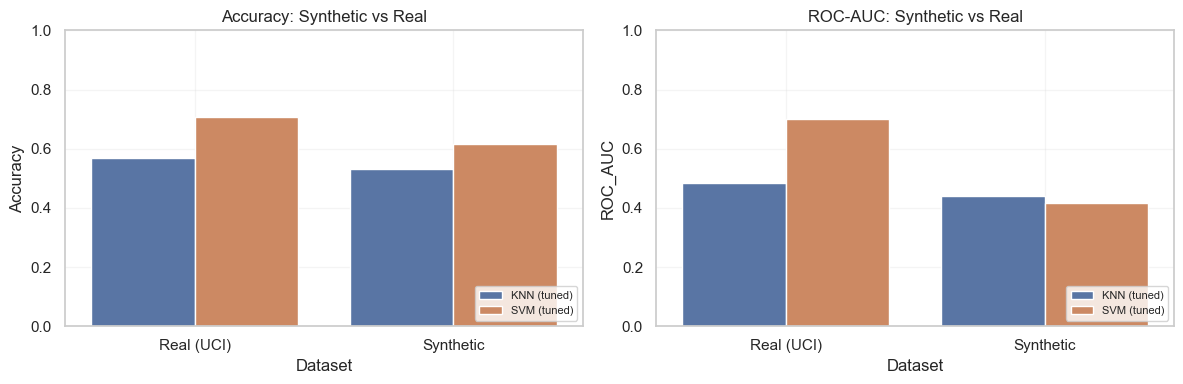

Saved comparison figure to results/figures/01_synthetic_vs_real_comparison.png


In [9]:
best_knn_real = knn_real_grid.best_estimator_
best_svm_real = svm_real_grid.best_estimator_

pred_knn_real = best_knn_real.predict(X_real_test)
pred_svm_real = best_svm_real.predict(X_real_test)

proba_knn_real = best_knn_real.predict_proba(X_real_test)[:, 1]
proba_svm_real = best_svm_real.predict_proba(X_real_test)[:, 1]

real_metrics_table = pd.DataFrame([
    {
        'Dataset': 'Real (UCI)',
        'Model': 'KNN (tuned)',
        'Accuracy': accuracy_score(y_real_test, pred_knn_real),
        'ROC_AUC': roc_auc_score(y_real_test, proba_knn_real),
    },
    {
        'Dataset': 'Real (UCI)',
        'Model': 'SVM (tuned)',
        'Accuracy': accuracy_score(y_real_test, pred_svm_real),
        'ROC_AUC': roc_auc_score(y_real_test, proba_svm_real),
    },
])

synthetic_metrics_labeled = metrics_table.copy()
synthetic_metrics_labeled['Dataset'] = 'Synthetic'

comparison_metrics = pd.concat(
    [synthetic_metrics_labeled[['Dataset', 'Model', 'Accuracy', 'ROC_AUC']], real_metrics_table],
    ignore_index=True,
).sort_values(by=['Dataset', 'Model']).reset_index(drop=True)

comparison_metrics[['Accuracy', 'ROC_AUC']] = comparison_metrics[['Accuracy', 'ROC_AUC']].round(3)
display(comparison_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=comparison_metrics, x='Dataset', y='Accuracy', hue='Model', ax=axes[0])
axes[0].set_title('Accuracy: Synthetic vs Real')
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison_metrics, x='Dataset', y='ROC_AUC', hue='Model', ax=axes[1])
axes[1].set_title('ROC-AUC: Synthetic vs Real')
axes[1].set_ylim(0, 1)

for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_synthetic_vs_real_comparison.png', dpi=150)
plt.show()

print('Saved comparison figure to results/figures/01_synthetic_vs_real_comparison.png')

## 5) Findings (Synthetic vs Real Comparison Included)
1. K-Means identifies separable engagement behavior groups on the synthetic dataset, with silhouette score around the chosen $k=3$.
2. Tuned KNN and tuned SVM provide baseline classification behavior on synthetic retention-risk labels.
3. Real-data comparison on UCI Student Performance (using a dropout-risk proxy from `G3 < 10`) shows measurable performance differences vs synthetic data.
4. The synthetic-vs-real gap is expected and is documented as a transferability limitation in portfolio documentation.
5. Next iteration will extend this comparison to ANN and deep models under compatible TensorFlow runtime conditions.